# GCAP3226 Week 3 — Graded in-class exercise
## Interpretation + Copilot stacked-bar visualization (5%)

**Individual** · submit via **your GitHub fork** (see below).

**Prerequisite:** You completed Class 1 (`W3_msw_regression.ipynb`) — same data and association story.

### What is marked
- **Part A:** **interpretation** of the Class 1 chart (direction + anti-claim)
- **Part B:** hypothesis + your own two-variable stacked bar
- **Part C:** one **Checkpoint** + plain-language close (**about your Part B chart**)


## How to use AI in this exercise

For the Checkpoint and written tasks, follow **three steps**:

1. **Think first** — draft your own answer even rough notes.  
2. **Use AI to check** — you may ask Copilot or ChatGPT to review wording, spot gaps, or suggest edits.  
3. **Read and verify** — read AI’s reply carefully; keep only what still fits **this sample** and **association-only** rules. You are responsible for your final wording.

**Two reasons we use this workflow:**
1. **Writing your own draft tests understanding.** Producing an initial answer is an effective way to check whether you grasp the idea and can express it accurately. Resist the urge to skip it—thinking it through yourself is how you learn.
2. **Fluent AI output is not always correct.** AI can sound confident and polished while still **overstating claims** or using **wording that does not match the evidence** (e.g. causation, generalisation beyond this sample). Step 3 is when **you** catch that.


## Part 0 — Setup (run cells)

Rebuild Class 1’s primary table. Survey wording is on the PPT.


In [15]:
# Purpose of this cell:
# Imports for the graded exercise (same stack as Class 1).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("Imports OK")


Imports OK


In [ ]:
# Purpose of this cell:
# Load GCAP3226_week3.csv from THIS repo folder (Codespace / fork) 

from pathlib import Path

DATA_FILE = "GCAP3226_week3.csv"

def load_week3_data():
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print(f"Using data file: {p.resolve()}")
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Open a Codespace from your Week 3 fork — "
        "do not use a path from your laptop."
    )

df = load_week3_data()
print("shape:", df.shape)
df[["support_info", "government_consideration", "fairness"]].head()


Using data file: /Users/taliawu/Desktop/Migration/2526AY_JupyterNotebook/GCAP3226_week3.csv
shape: (97, 43)


,support_info,government_consideration,fairness
0,1,1,1
1,5,5,5
2,3,4,5
3,1,1,2
4,1,3,4


Row percentages (%):
support_info                 1     2     3     4     5
government_consideration                              
1                         72.7  27.3   0.0   0.0   0.0
2                         12.5  41.7  25.0  12.5   8.3
3                          3.0   9.1  42.4  36.4   9.1
4                          0.0   0.0  18.8  68.8  12.5
5                          0.0   0.0   0.0  50.0  50.0

Row n:
government_consideration
1    22
2    24
3    33
4    16
5     2
dtype: int64


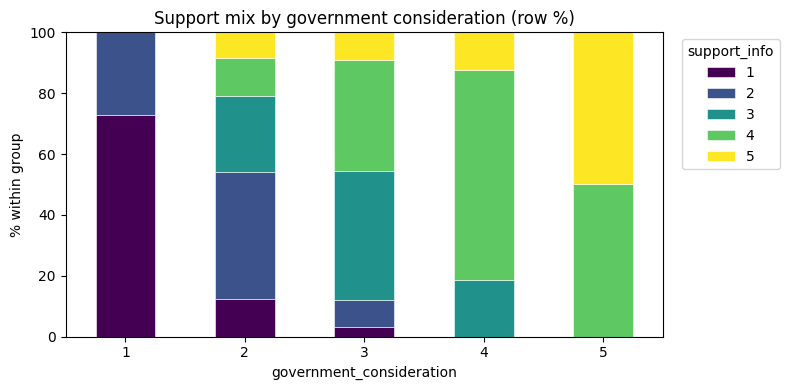

In [16]:
# Purpose of this cell:
# Primary view: counts, row %, stacked bar (same as Class 1).
# You need this chart for Part A Tasks 1–2.

work = df[["support_info", "government_consideration"]].dropna()
counts = pd.crosstab(work["government_consideration"], work["support_info"])
row_pct = pd.crosstab(
    work["government_consideration"],
    work["support_info"],
    normalize="index",
) * 100

print("Row percentages (%):")
print(row_pct.round(1))
print("\nRow n:")
print(counts.sum(axis=1))

ax = row_pct.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="viridis", edgecolor="white", linewidth=0.4)
ax.set_xlabel("government_consideration")
ax.set_ylabel("% within group")
ax.set_title("Support mix by government consideration (row %)")
ax.legend(title="support_info", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Purpose of this cell:
# Single-number trend summary — one compact number summarising direction (from treating Likert scores as numbers). Not causal proof.
# Main evidence is the row % table and stacked bar above.

model = LinearRegression()
model.fit(work[["government_consideration"]], work["support_info"])
beta1 = model.coef_[0]
print("Main evidence: row % table and stacked bar (cells above).")
print(f"Single-number trend summary: {beta1:.3f}")
print("Read the chart first; this summary is not proof of causation.")


## Part A — Interpretation of the Part 0 chart

This section is about the **given** stacked bar: `government_consideration` × `support_info` (same as Class 1).

**Think first:** write your own answer in each **code cell** below (edit the Python cells — not the markdown instructions).  
**Then (optional):** use AI to check wording — follow the three steps at the top.


### Task 1 — Direction from the percentages

> Looking at the **row % / stacked bar**, as **government_consideration** moves from low to high, the share of respondents at __________ support levels tends to __________, **in this sample**.


In [5]:
# Purpose of this cell:
# Task 1 — your sentence from the stacked-bar story. Draft first, then verify if you use AI.

task1 = """
Looking at the row % / stacked bar, as government_consideration moves from low to high ...
"""
print(task1)



Looking at the row % / stacked bar, as government_consideration moves from low to high ...



### Task 2 — Anti-claim

> We would **not** tell a district audience that government consideration *causes* higher support for MSW charging because __________.


In [ ]:
# Purpose of this cell:
# Task 2 — anti-claim. Draft first, then verify if you use AI.

task2 = """
We would not tell a district audience that government consideration causes higher support because ...
"""
print(task2)


## Part B — Copilot stacked bar (two variables)

Choose **two** variables from the allowlist below. Build a **stacked bar chart of row percentages** (same idea as Class 1): within each level of your **group** variable, show the % at each level of your **stack** variable.

### Allowlist — survey & policy variables

| Variable | Scale | Topic (short) |
|----------|-------|----------------|
| `support_info` | 1–5 | Initial support for MSW charging |
| `support_after_info` | 1–5 | Support after landfill + Korea information |
| `fairness` | 1–5 | Polluter-pays / burden fairness |
| `government_consideration` | 1–5 | Government considered diverse opinions |
| `policy_helpfulness` | 1–4 | Perceived helpfulness of the policy |
| `waste_severity` | 1–4 | Perceived waste problem severity |
| `recycling_effort` | 1–4 | Time/effort to recycle |
| `recycle_frequency` | 1–5 | How often respondent recycles |
| `food_waste_behavior` | 3 categories | Food-waste handling behaviour |
| `household_size` | 1–6 | People in household |
| `LocalResidentcode` | 0/1 | Local resident indicator |

### Your hypothesis (before you chart)

**Draft first** (before Copilot): state a **research question** in plain language — **why** did you choose these two variables? What pattern might you expect to see in **this sample**?

Use **association** language (may / might / tend to), not causation (will / causes).

*Example:* “Among respondents in this sample, as perceived fairness increases, the share at higher support levels **may** also increase.”

**Roles for your chart:**
- **Group (x-axis):** one variable — bars side by side (e.g. `government_consideration`).
- **Stack (colours):** the other variable — segments show **row %** within each group (e.g. `support_info`).

Both variables should be **categorical or ordered categories** for this exercise.

**Steps:**
1. Write your **hypothesis / research question** (why these two variables).  
2. Name your **two** variables and which is **group** vs **stack**.  
3. Write a **Copilot prompt** as a `#` comment (e.g. `# stacked bar row % of support_info by fairness`).  
4. **Run** the code and **verify** labels match the survey (PPT / column names).  

Part C asks you to interpret **your** chart in policy language.



In [20]:
# Purpose of this cell:
# Step 1 — hypothesis or research question (draft first; then optional AI verify).
# Why these two variables? What pattern might you expect in this sample?

viz_hypothesis = """
Research question or hypothesis (association only, not causation):
I chose these two variables because ...
"""
print(viz_hypothesis)




Research question or hypothesis (association only, not causation):
I chose these two variables because ...



In [ ]:
# Purpose of this cell:
# Step 2 — two allowlist variables and chart roles.

viz_group = "government_consideration"  # x-axis: groups (bars)
viz_stack = "support_info"              # stack segments: row % within each group

print("Group (x-axis):", viz_group)
print("Stack (row %):", viz_stack)



Group (x-axis): government_consideration
Stack (row %): support_info


Row percentages (%):
support_info                 1     2     3     4     5
government_consideration                              
1                         72.7  27.3   0.0   0.0   0.0
2                         12.5  41.7  25.0  12.5   8.3
3                          3.0   9.1  42.4  36.4   9.1
4                          0.0   0.0  18.8  68.8  12.5
5                          0.0   0.0   0.0  50.0  50.0

Row n:
government_consideration
1    22
2    24
3    33
4    16
5     2
dtype: int64


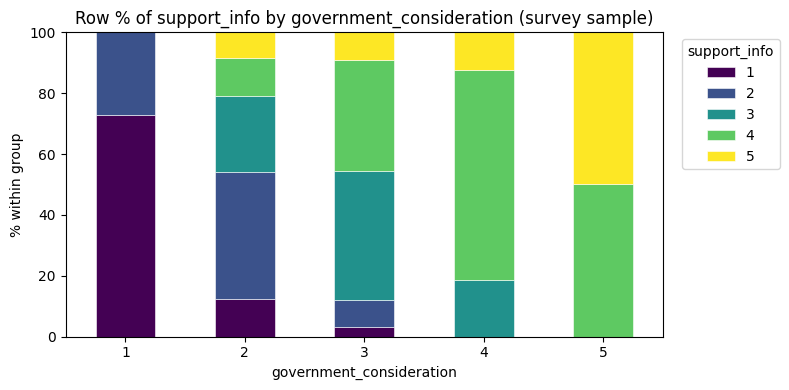

In [ ]:
# Purpose of this cell:
# Step 3–4 — Copilot prompt + stacked bar (row %). 
# Edit variables above, then run.

# Copilot example:
# stacked bar chart of row percentages: 
# support_info within each government_consideration group

pair = df[[viz_group, viz_stack]].dropna()
counts = pd.crosstab(pair[viz_group], pair[viz_stack])
row_pct = pd.crosstab(pair[viz_group], pair[viz_stack], normalize="index") * 100

print("Row percentages (%):")
print(row_pct.round(1))
print("\nRow n:")
print(counts.sum(axis=1))

ax = row_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4),
    colormap="viridis",
    edgecolor="white",
    linewidth=0.4,
)
ax.set_xlabel(viz_group)
ax.set_ylabel("% within group")
ax.set_title(f"Row % of {viz_stack} by {viz_group} (survey sample)")
ax.legend(title=viz_stack, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Part C — Interpret **your Part B chart**

Answer below about the **stacked bar you built in Part B** (your two variables — not the Part 0 chart).

**Think first** → **use AI to check** → **read and verify**.


### Checkpoint

**In one sentence:** what were you trying to learn about **MSW charging** from the **two variables** in your Part B chart?

*Example (if group = `fairness`, stack = `support_info`):*  
“In this sample, is higher perceived fairness of polluter-pays charging **associated with** a different mix of support for MSW charging?”




In [ ]:
# Purpose of this cell:
# Checkpoint — policy question for YOUR Part B chart. Draft first.

checkpoint = """
# One sentence — policy question your Part B chart explores:
"""
print(checkpoint)



### Plain-language close

Write **1–2 sentences** a non-technical reader could use about **your Part B chart**.

Include:
- what you **found** in this sample, and  
- **one caution** (e.g. non-random sample, small group *n*, association ≠ causation, or wording that could mislead if overstated).


In [ ]:
# Purpose of this cell:
# Plain-language close — about YOUR Part B chart. Draft first; optional AI check for clarity.

plain_language = """
# 1–2 sentences for a non-technical reader:
"""
print(plain_language)


### AI verification note

If you used Copilot or ChatGPT to **check** your answers, paste **one** exchange: what you drafted, what you changed after reading AI’s reply, and why.


In [ ]:
# Purpose of this cell:
# Optional bonus — think → check with AI → verify reflection.

ai_verify_note = """
(optional) I drafted: ...
AI suggested: ...
I kept/changed because ...
"""
print(ai_verify_note)


## How to submit (GitHub link on Moodle)

Practice what you learned in Week 2:

1. **Save** the notebook (`File → Save`).  
2. **Commit** your changes (Source Control → **+** stage → message → **Commit**).  
3. **Push** to **your fork** on github.com (**Sync / Push**).  
4. On Moodle, submit the **link to this file in your fork**: open `W3_msw_inclass.ipynb` on github.com → copy the browser URL.

**If push fails:** Save → **Download** the `.ipynb` and upload to Moodle instead (see Week 2 `README.md`).

### Submission checklist

- [ ] Part 0: row % / stacked bar ran  
- [ ] Part A: Task 1 and Task 2 filled  
- [ ] Part B: hypothesis + two allowlist variables + stacked bar (row %)  
- [ ] Part C: **Checkpoint** + plain-language close about **your** Part B chart
- [ ] Notebook **saved**, **committed**, and **pushed** to your fork  
- [ ] Moodle: GitHub link submitted (or `.ipynb` upload if push failed)
